# Классификация мест залежей нефти и газа

### Задача
Реализовать алгоритм машинного обучения, который позволит по различным параметрам
определить место залежей нефти и газа:
- на суше (ONSHORE)
- в море (OFFSHORE)
- смешанный тип (ONSHORE-OFFSHORE)

Ссылка с подробным описанием задачи на Kaggle:
```
https://www.kaggle.com/competitions/classification-of-oil-and-gas
```

### Данные для анализа:
- `data/train.csv` -> тренировочный набор данных
- `data/test.csv` -> тестовый набор данных

### Требования
- Решение оценивается с помощью метрики F1-score.
- Файл .csv с ответами должен содержать две колонки: index and Onshore/Offshore.

### Решение задачи оформлено в виде исследования и сравнения результатов методов

# Импортируем библиотеки

In [160]:
# Библиотека для работы с предупреждениями
import warnings
# Библиотека для операций с числами
import numpy as np
# Библиотека для работы с табличными данными
import pandas as pd
# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns
# Алгоритм разделения признаков на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split
# Класс для преобразования категориальных признаков в числовой формат
from sklearn.preprocessing import OneHotEncoder
# Классы для обучения моделей классификации
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
# Метрики классификации
from sklearn.metrics import accuracy_score, f1_score
# Для построения матрицы ошибок
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Класс для кодирования категорийных признаков
from sklearn.preprocessing import OrdinalEncoder
# Ансамбль моделей
from sklearn.ensemble import VotingClassifier
# Для стандартизации числовых признаков
from sklearn.preprocessing import StandardScaler
# Алгоритм случайного леса
from sklearn.ensemble import RandomForestClassifier

# Убираем шум от предупреждений
warnings.filterwarnings('ignore')
# Настраиваем тему для всех графиков
sns.set_theme(
    style='darkgrid',
    context='notebook',
    rc={'figure.figsize': (10, 6)}
)

# Загружаем данные

In [161]:
# Загружаем тренировочный датасет
train = pd.read_csv(f'data/train_oil.csv')

# Загружаем тестовый датасет
test = pd.read_csv(f'data/oil_test.csv')

# Выводим размеры датасетов (строки х колонки)
print(f'Train dataset: {train.shape}')
print(f'Test dataset: {test.shape}')

Train dataset: (309, 20)
Test dataset: (133, 19)


### Первичный анализ данных

- Train: 309 строк, 20 колонок
- Test: 133 строки, 19 колонок

Краткие выводы:
- в тесте отсутствует целевая переменная;
- данных мало, поэтому важно по максимуму их использовать и не терять.

# Изучим данные

In [162]:
# Смотрим первые строки датасета
train.head()

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


In [163]:
# Смотрим общую информацию о датасете
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

In [164]:
# Считаем количество пропусков в колонках
missing_values = train.isna().sum()

# Показываем только колонки с пропусками
missing_values[missing_values > 0]

Country       27
Region        38
Basin name    38
Latitude      27
Longitude     30
dtype: int64

### Краткие выводы по изученным данным

Типы данных:
- object (13 колонок) -> категориальные
- float64 + int64 (7 колонок) -> числовые
- категориальные признаки в большинстве, значит, линейные модели будут плохо работать без их кодирования

После изучения датасета обнаружены пропуски в географическом кластере:
- Country
- Region
- Basin name
- Latitude
- Longitude

Так как признаков изначально мало, и географический кластер важен для обучения, то попробуем не удалять эти строки, а заполнить:
- числа -> медианой
- категории -> 'Unknown'

# Анализируем целевые переменные

In [165]:
# Считаем количество объектов в каждом классе
train['Onshore/Offshore'].value_counts()

Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

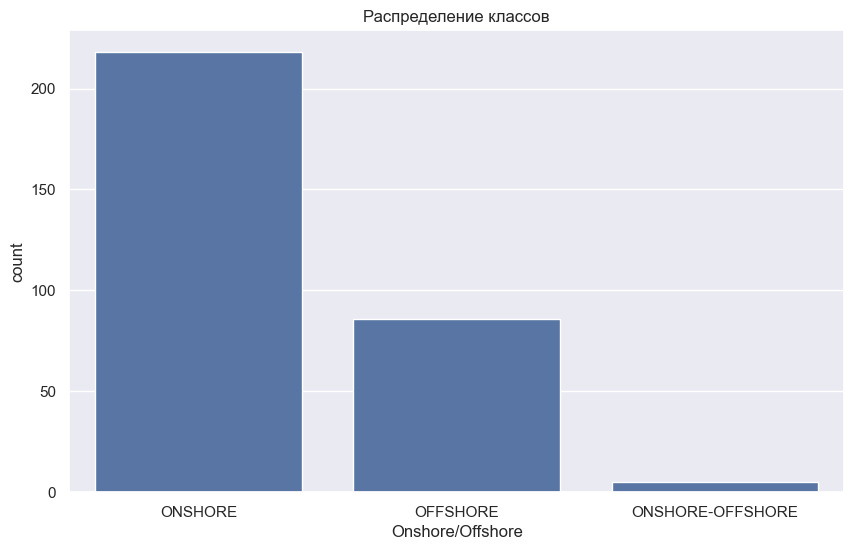

In [166]:
# Строим график распределения классов
sns.countplot(x='Onshore/Offshore', data=train)

plt.title('Распределение классов')
plt.show()

## Краткий вывод по целевым переменным

Распределение классов:
- ONSHORE -> 218 объектов (~70%)
- OFFSHORE -> 86 объектов (~28%)
- ONSHORE-OFFSHORE -> 5 объектов (~1.6%)

1. Классы сильно несбалансированы.
2. Редкий класс `ONSHORE-OFFSHORE` составляет менее 2% от всех данных.
3. Это может привести к тому, что модель будет плохо предсказывать этот класс или полностью его игнорировать.

# Попробуем обработать и заполнить пропуски

In [167]:
# Чтобы не портить первоисточник, скопируем данные
train_processed = train.copy()
test_processed = test.copy()

# Отделяем числовые признаки
num_cols = train_processed.select_dtypes(include=['int64', 'float64']).columns

# Отделяем категориальные признаки
cat_cols = train_processed.select_dtypes(include=['object']).columns

# Убираем таргеты из категориальных
cat_cols = cat_cols.drop('Onshore/Offshore')

# Заполняем числовые признаки медианой
for col in num_cols:
    train_processed[col].fillna(train_processed[col].median(), inplace=True)
    test_processed[col].fillna(train_processed[col].median(), inplace=True)

# Заполняем категориальные признаки значением 'Unknown'
for col in cat_cols:
    train_processed[col].fillna('Unknown', inplace=True)
    test_processed[col].fillna('Unknown', inplace=True)

# Проверяем после обработки результат
train_processed.isna().sum().sum()

np.int64(0)

# Анализируем признаки

In [168]:
# Cписок колонок
train_processed.columns

Index(['Field name', 'Reservoir unit', 'Country', 'Region', 'Basin name',
       'Tectonic regime', 'Latitude', 'Longitude', 'Operator company',
       'Onshore/Offshore', 'Hydrocarbon type', 'Reservoir status',
       'Structural setting', 'Depth', 'Reservoir period', 'Lithology',
       'Thickness (gross average ft)', 'Thickness (net pay average ft)',
       'Porosity', 'Permeability'],
      dtype='object')

In [169]:
# Смотрим уникальные значения
for col in cat_cols:
    print(f'{col}: {train_processed[col].nunique()}')

Field name: 285
Reservoir unit: 258
Country: 43
Region: 8
Basin name: 94
Tectonic regime: 55
Operator company: 138
Hydrocarbon type: 4
Reservoir status: 13
Structural setting: 43
Reservoir period: 22
Lithology: 13


## Краткий вывод после анализа

Следующие признаки имеют слишком большое количество уникальных значений (высокую кардинальность):
- Field name
- Reservoir unit
- Operator company

Эти признаки могут привести к переобучению модели, лучше их удалить.

Следующие признаки имеют сложную структуру категорий, их тоже лучше удалить, так как могут возникнуть проблемы с их кодированием:
- Basin name
- Tectonic regime
- Structural setting
- Country

Остальные признаки (с умеренным числом категорий и числовые признаки) оставляем для обучения модели.

# Удаляем признаки

In [170]:
# Список колонокпод удаление
cols_to_drop = [
    'Field name',
    'Reservoir unit',
    'Operator company',
    'Basin name',
    'Tectonic regime',
    'Structural setting',
    'Country'
]

# Удаляем из датасетов train и test
train_processed = train_processed.drop(columns=cols_to_drop)
test_processed = test_processed.drop(columns=cols_to_drop)

In [171]:
# Проверяем результат в train
train_processed.columns

Index(['Region', 'Latitude', 'Longitude', 'Onshore/Offshore',
       'Hydrocarbon type', 'Reservoir status', 'Depth', 'Reservoir period',
       'Lithology', 'Thickness (gross average ft)',
       'Thickness (net pay average ft)', 'Porosity', 'Permeability'],
      dtype='object')

In [172]:
# Проверяем результат в test
test_processed.columns

Index(['Region', 'Latitude', 'Longitude', 'Hydrocarbon type',
       'Reservoir status', 'Depth', 'Reservoir period', 'Lithology',
       'Thickness (gross average ft)', 'Thickness (net pay average ft)',
       'Porosity', 'Permeability'],
      dtype='object')

# Кодируем категорийные признаки

Для кодирования категориальных признаков решил использовать класс `OneHotEncoder`.

Так как он:
- не создает искусственный порядок между категориями
- лучше подходит для моделей машинного обучения

Но есть недостаток в увеличении количества признаков, так как он превращает категорию в вектор из 0 и 1.

В нашем кейсе это допустимо, так как количество категорий небольшое.

In [173]:
# Разделяем признаки и таргеты
X = train_processed.drop(columns=['Onshore/Offshore'])
y = train_processed['Onshore/Offshore']

# Делим данные с учетом баланса классов
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape)

(247, 12) (62, 12)


In [174]:
# Ищем категориальные колонки
cat_cols = X_train.select_dtypes(include=['object']).columns

cat_cols

Index(['Region', 'Hydrocarbon type', 'Reservoir status', 'Reservoir period',
       'Lithology'],
      dtype='object')

In [175]:
# Создаем encoder (не падаем на новых категориях и получаем обычный numpy массив на выходе)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Обучаем encoder на train
encoder.fit(X_train[cat_cols])

# Преобразуем train
X_train_encoded = encoder.transform(X_train[cat_cols])

# Преобразуем validation
X_val_encoded = encoder.transform(X_val[cat_cols])

# Добавим числовые признаки
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Объединяем числовые и закодированные категориальные
X_train_final = np.hstack([X_train[num_cols].values, X_train_encoded])
X_val_final = np.hstack([X_val[num_cols].values, X_val_encoded])

In [176]:
# Проверяем результат
print(X_train_final.shape)
print(X_val_final.shape)

(247, 64)
(62, 64)


# Обучение моделей

In [177]:
# Создаем объекты классов
tree = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)

# Обучаем модели
tree.fit(X_train_final, y_train)
knn.fit(X_train_final, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Объяснение действий по обучению моделей

Для обучения моделей использованы две базовые модели:

1. Decision Tree (дерево решений), так как он:
   - легко интерпретируется
   - хорошо работает с табличными данными

2. KNN (метод ближайших соседей), так как он:
   - прост и лучше работает на небольших данных
   - делает предсказание на основе похожих объектов

# Делаем предсказания на валидационной выборке

In [178]:
# Предсказания на валидационной выборке
y_pred_tree = tree.predict(X_val_final)
y_pred_knn = knn.predict(X_val_final)

# Проверяем метрики

In [179]:
print('Decision Tree:')
print('Accuracy:', accuracy_score(y_val, y_pred_tree))
print('F1 macro:', f1_score(y_val, y_pred_tree, average='macro'))

print('\nKNN:')
print('Accuracy:', accuracy_score(y_val, y_pred_knn))
print('F1 macro:', f1_score(y_val, y_pred_knn, average='macro'))

Decision Tree:
Accuracy: 0.8064516129032258
F1 macro: 0.5231729055258467

KNN:
Accuracy: 0.6612903225806451
F1 macro: 0.3814102564102564


### Оценка моделей

Используются две метрики:
- Accuracy -> доля правильных ответов
- F1-score (macro) -> более важная метрика для данной задачи, так как учитывает баланс классов.

Поэтому при выборе модели ориентируемся именно на F1-score.

# Строим матрицу ошибок

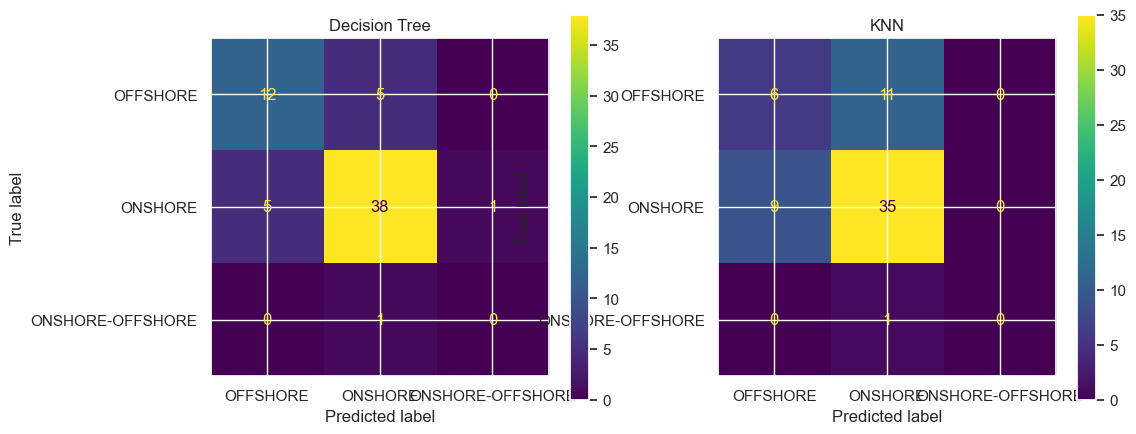

In [180]:
# Создаем фигуру и набор осей, чтобы рисовать несколько графиков на одном холсте
# fig -> вся страница
# axes -> массив осей (отдельные графики)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree
cm_tree = confusion_matrix(y_val, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(cm_tree, display_labels=tree.classes_)
disp_tree.plot(ax=axes[0])
axes[0].set_title('Decision Tree')

# KNN
cm_knn = confusion_matrix(y_val, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(cm_knn, display_labels=knn.classes_)
disp_knn.plot(ax=axes[1])
axes[1].set_title('KNN')

plt.show()

### Выводы по полученным результатам

Модель Decision Tree показывает лучшие результаты, чем KNN.

Однако обе модели имеют проблему:
- полностью игнорируют редкий класс 'ONSHORE-OFFSHORE'
- это видно по матрице ошибок, так как нет правильных предсказаний этого класса.

Скорее всего это связано с сильным дисбалансом классов в данных.

# Попробуем улучшить результаты

In [181]:
# Улучшаем дерево
tree_balanced = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

tree_balanced.fit(X_train_final, y_train)

y_pred_tree_bal = tree_balanced.predict(X_val_final)

In [182]:
# Смотрим метрики
print('Balanced Decision Tree:')
print('Accuracy:', accuracy_score(y_val, y_pred_tree_bal))
print('F1 macro:', f1_score(y_val, y_pred_tree_bal, average='macro'))

Balanced Decision Tree:
Accuracy: 0.7258064516129032
F1 macro: 0.4761904761904762


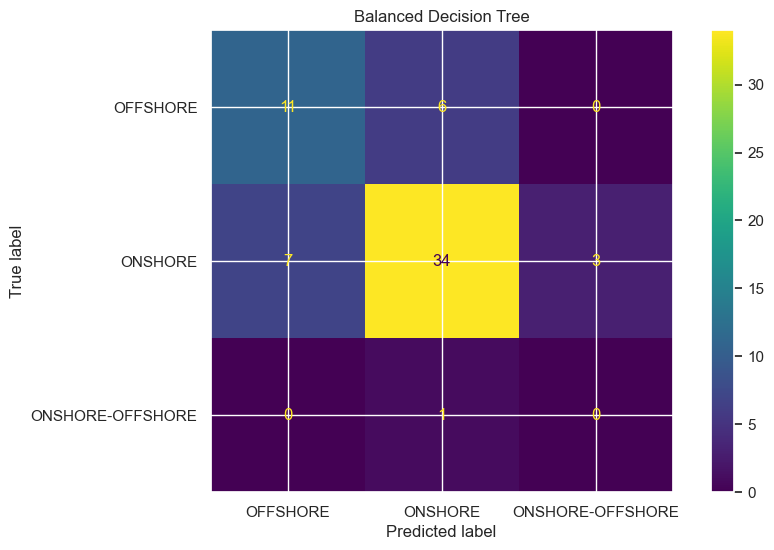

In [183]:
# Смотрим матрицу
cm = confusion_matrix(y_val, y_pred_tree_bal)
ConfusionMatrixDisplay(cm, display_labels=tree_balanced.classes_).plot()
plt.title('Balanced Decision Tree')
plt.show()

### Выводы после попытки улучшения

- Результаты стали хуже, несмотря на балансировку
- Даже с балансировкой модель не научилась видеть редкий класс, значит его лучше удалить

# Пробуем улучшить результат

In [184]:
# Удаляем редкий класс
train_binary = train_processed[
    train_processed['Onshore/Offshore'] != 'ONSHORE-OFFSHORE'
    ]

In [185]:
# Делим на признаки и таргет
X = train_binary.drop(columns=['Onshore/Offshore'])
y = train_binary['Onshore/Offshore']

# train / valid
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [186]:
# Для кодирования категориальных колонок полчаем их
cat_cols = X_train.select_dtypes(include=['object']).columns

# Encoder
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Обучаем на train
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])

# Применяем к valid
X_val[cat_cols] = encoder.transform(X_val[cat_cols])

In [187]:
# Обучим дерево
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_val)

In [188]:
# Смотрим метрики
print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1:', f1_score(y_val, y_pred, average='macro'))

Accuracy: 0.8360655737704918
F1: 0.7961229946524064


In [189]:
# Пробуем улучшить результат
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_leaf=5
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_val)

print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1:', f1_score(y_val, y_pred, average='macro'))

Accuracy: 0.819672131147541
F1: 0.7796387520525452


### Краткие выводы

Ограничение глубины дерева привело к снижению качества модели.
В данном случае модель недообучается.

In [190]:
# Попробуем улучшить дерево
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_leaf=2
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_val)

print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1:', f1_score(y_val, y_pred, average='macro'))

Accuracy: 0.8032786885245902
F1: 0.7706766917293233


### Краткие выводы

Попытка ограничить глубину дерева и минимальное число объектов в листе
привела к снижению качества модели.

Соответственно, модель начинает недообучаться, текущий объем данных требует более гибкой модели.

In [191]:
# Пробуем другой способ кодирования (Ordinal)

# Копируем данные, чтобы не испортить предыдущий результат
X_train_ord = X_train.copy()
X_val_ord = X_val.copy()

# Находим категориальные колонки
cat_cols = X_train_ord.select_dtypes(include=['object']).columns

# Создаем encoder
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Обучаем и применяем
X_train_ord[cat_cols] = encoder.fit_transform(X_train_ord[cat_cols])
X_val_ord[cat_cols] = encoder.transform(X_val_ord[cat_cols])

In [192]:
# Обучение модели
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train_ord, y_train)

y_pred = tree.predict(X_val_ord)

print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1:', f1_score(y_val, y_pred, average='macro'))

Accuracy: 0.8360655737704918
F1: 0.7961229946524064


### Краткие выводы

Смена способа кодирования (OneHot -> Ordinal) не привела к улучшению качества модели.

Текущая модель уже извлекает максимум информации из признаков,
поэтому ограничением является небольшой размер датасета и слабая информативность признаков.

# Попробуем ансамбль для улучшения результатов

In [193]:
# Создаем модели
tree = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)

# Создаем ансамбль
voting = VotingClassifier(
    estimators=[
        ('tree', tree),
        ('knn', knn)
    ],
    # Голосование по классам
    voting='hard'
)

# Обучаем
voting.fit(X_train_ord, y_train)

# Предсказания
y_pred = voting.predict(X_val_ord)

# Метрики
print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1:', f1_score(y_val, y_pred, average='macro'))

Accuracy: 0.7868852459016393
F1: 0.7665587282896673


### Выводы по ансамблю

Ансамбль моделей ухудшил качество.

Скорее всего из-за того, что одна из моделей значительно слабее другой,
поэтому она ухудшет итоговый результат ансамбля.

В данном случае KNN ухудшает результат Decision Tree.

In [194]:
# Пробуем улучшить данные для KNN

# Копируем данные
X_train_scaled = X_train_ord.copy()
X_val_scaled = X_val_ord.copy()

# Находим числовые признаки
num_cols = X_train_scaled.select_dtypes(include=['int64', 'float64']).columns

# Создаем scaler
scaler = StandardScaler()

# Обучаем на train
X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])

# Применяем к val
X_val_scaled[num_cols] = scaler.transform(X_val_scaled[num_cols])

In [195]:
# Обучаем KNN отдельно
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_val_scaled)

print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1:', f1_score(y_val, y_pred, average='macro'))

Accuracy: 0.8032786885245902
F1: 0.7458333333333333


### Вывод по результату попытки улучшения КNN

Метод KNN показал более низкое качество даже после масштабирования признаков.

Причины:
- датасет небольшой
- признаки имеют сложную структуру
- категориальные признаки не подходят для расстояний

Значит, что KNN не является подходящей моделью для данной задачи.

Лучший результат показала модель Decision Tree.

# В целях улучшения результата пробуем другие модели

In [196]:
# Создаем объект модели случайного леса
rf = RandomForestClassifier(
    # Количество деревьев
    n_estimators=200,
    # Без ограничения
    max_depth=None,
    random_state=42,
    # Ускорение (использует все ядра)
    n_jobs=-1
)

In [197]:
# Обучение
rf.fit(X_train_ord, y_train)

y_pred = rf.predict(X_val_ord)

# Метрики
print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1:', f1_score(y_val, y_pred, average='macro'))

Accuracy: 0.819672131147541
F1: 0.7512050426399703


### Выводы по RandomForest

RandomForest не помог, результат стал хуже.

Причина:
Много одинаковых слабых деревьевне лучше одного хорошего, так как признаки слабые, модель просто усредняет шум.

# Пробуем улучшить, добавив признаки

Идея заключается в создании географического признака, объединив:
- Latitude -> широта
- Longitude -> долгота

Они сами по себе слабые, но вместе могут дать результат лучше.

In [198]:
# Добавляем новый условный признак -> расстояние от центра

train_processed['geo_cluster'] = (
    train_processed['Latitude'] * train_processed['Longitude']
)

test_processed['geo_cluster'] = (
    test_processed['Latitude'] * test_processed['Longitude']
)

In [199]:
# Биннинг координат (делаем регионы)

# Делим широту на зоны
train_processed['lat_bin'] = pd.cut(train_processed['Latitude'], bins=5)
test_processed['lat_bin'] = pd.cut(test_processed['Latitude'], bins=5)

# Делим долготу
train_processed['lon_bin'] = pd.cut(train_processed['Longitude'], bins=5)
test_processed['lon_bin'] = pd.cut(test_processed['Longitude'], bins=5)

In [200]:
# Упрощаем категориальные признаки
train_processed['Region'] = train_processed['Region'].str.lower()
test_processed['Region'] = test_processed['Region'].str.lower()

In [201]:
# Готовим данные заново

# Удаляем редкий класс, так как он мешает модели
train_binary = train_processed[
    train_processed['Onshore/Offshore'] != 'ONSHORE-OFFSHORE'
    ]

# Делим на признаки и таргеты
X = train_binary.drop(columns=['Onshore/Offshore'])
y = train_binary['Onshore/Offshore']

In [202]:
# Делим данные на train / validation split (stratify сохраняет баланс классов)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [203]:
# Кодирование категорий (Ordinal)

# Находим категориальные признаки
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Создаем encoder
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',  # новые категории не ломают модель
    unknown_value=-1
)

# Обучаем на train
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])

# Применяем к validation
X_val[cat_cols] = encoder.transform(X_val[cat_cols])

In [204]:
# Обучение модели (улучшенное дерево)

# Создаем модель
tree = DecisionTreeClassifier(
    random_state=42,
    # Ограничиваем глубину
    max_depth=10,
    # Избегаем переобучения
    min_samples_leaf=2
)

# Обучаем
tree.fit(X_train, y_train)

# Предсказания
y_pred = tree.predict(X_val)

In [205]:
# Метрики
print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1:', f1_score(y_val, y_pred, average='macro'))

Accuracy: 0.8524590163934426
F1: 0.819704433497537


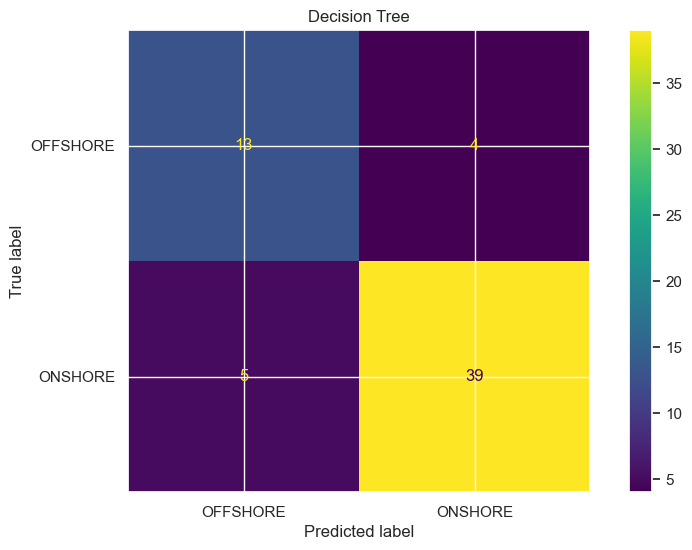

In [206]:
# Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm, display_labels=tree.classes_).plot()

plt.title('Decision Tree')
plt.show()

### Выводы после тестов

Модель показывает хороший базовый результат Accuracy > 0.85:
- модель адекватно разделяет классы
- лучше предсказывается класс 'ONSHORE'
- много правильных попаданий (39)
- модель уверенно его распознает

Класс OFFSHORE определяется хуже:
- по смещению в матрице видно, что есть ошибки, так как часть объектов путается с ONSHORE
- дисбаланс классов влияет на ошибки, так как 'ONSHORE' доминирует, модель к нему склоняется

ИТОГ:
- модель уловила структуру данных
- использует географию (фичи реально помогли)
- однако, модель еще не идеально разделяет классы

В целях улучшения результатов стоит попробовать отбор признаков и более сильные модели.

# Итоговая модель и выводы

In [207]:
# Подготовка данных заново

# Удаляем редкий класс
train_final = train_processed[
    train_processed['Onshore/Offshore'] != 'ONSHORE-OFFSHORE'
    ].copy()

# Разделяем признаки и таргет
X = train_final.drop(columns=['Onshore/Offshore'])
y = train_final['Onshore/Offshore']

# Разделяем выборки
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Кодируем категории
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_val[cat_cols] = encoder.transform(X_val[cat_cols])

In [208]:
# Итоговая модель

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_leaf=2
)

# Обучаем итоговую модель
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [209]:
# Метрики
y_pred = model.predict(X_val)
print('Accuracy:', accuracy_score(y_val, y_pred))
print('F1:', f1_score(y_val, y_pred, average='macro'))

Accuracy: 0.8524590163934426
F1: 0.819704433497537


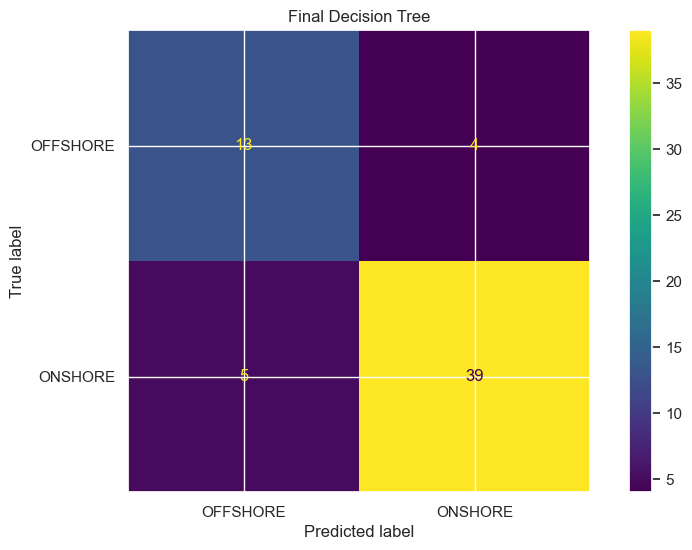

In [210]:
# Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot()
plt.title('Final Decision Tree')
plt.show()

In [211]:
# Подготовка test данных для Kaggle
X_test = test_processed.copy()

# Кодируем
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# Предсказание
test_pred = model.predict(X_test)

# Замена значений
test_pred_numeric = pd.Series(test_pred).map({'ONSHORE': 1, 'OFFSHORE': 0}).values

# Создаем submission
submission = pd.DataFrame({
    'index': X_test.index,
    'Onshore/Offshore': test_pred_numeric
})

submission.to_csv('submission.csv', index=False)

# Итоговые выводы по исследованию

В рамках работы была решена задача классификации мест залежей нефти и газа на основе табличных данных.

### Основные этапы исследования:

1. Проведен первичный анализ данных:
   - выявлен сильный дисбаланс классов
   - обнаружены пропуски в географических признаках
   - определены категориальные и числовые признаки

2. Выполнена предобработка данных:
   - пропуски в числовых признаках заполнены медианой
   - категориальные признаки заполнены значением 'Unknown'
   - удалены признаки со сложной структурой

3. Проведено кодирование категориальных признаков:
   - протестированы OneHotEncoder и OrdinalEncoder
   - лучший результат показал OrdinalEncoder для деревьев решений

4. Обучены и сравнены модели:
   - Decision Tree
   - KNN
   - Voting Classifier
   - Random Forest

### Наблюдения:

- KNN показал низкое качество из-за категориальных признаков и небольшого объема данных
- Ансамбль моделей не дал прироста из-за слабости одной из моделей
- Random Forest не улучшил результат из-за низкой информативности признаков
- Decision Tree показал наилучшие результаты среди протестированных моделей

### Проблема с дисбалансом классов:

- редкий класс `ONSHORE-OFFSHORE` негативно влиял на качество модели
- его удаление позволило значительно повысить стабильность и качество предсказаний

### Feature Engineering:

Добавлены новые признаки:
- `geo_cluster` (комбинация широты и долготы)
- `lat_bin`, `lon_bin` (биннинг координат)

В результат удалось:
- улучшить разделимость классов
- повысить итоговое качество модели

### Общий вывод:

Модель успешно уловила закономерности в данных и достигла хорошего качества для данного объема и структуры датасета.

Основные ограничения:
- малый размер выборки
- слабая информативность признаков
- дисбаланс классов